In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay
)

In [85]:
# ---------------------------------------------------------
# 1. Load data
# ---------------------------------------------------------
# Option A: local file
# df = pd.read_csv("credit_risk_dataset.csv")

# Option B: from GitHub/raw URL
url = "https://raw.githubusercontent.com/DaneshBU/CS506-Project/main/data/credit_risk_dataset.csv"
df = pd.read_csv(url)

print("Original dataset shape:", df.shape)
print(df.head())

Original dataset shape: (32581, 12)
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                     

In [86]:
# ---------------------------------------------------------
# 2. Basic cleaning
# ---------------------------------------------------------
df = df.drop_duplicates().copy()
print("\nAfter removing duplicates:", df.shape)

# target column
target_col = "loan_status"

# quick safety check
if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found in dataset.")

# Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col]

print("\nTarget distribution:")
print(y.value_counts(normalize=True))


After removing duplicates: (32416, 12)

Target distribution:
loan_status
0    0.781312
1    0.218688
Name: proportion, dtype: float64


In [87]:
# ---------------------------------------------------------
# 3. Detect numeric and categorical columns
# ---------------------------------------------------------
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("\nNumeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
Categorical features: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


/tmp/ipykernel_4348/1624583034.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


In [88]:
# ---------------------------------------------------------
# 4. Preprocessing pipelines
# ---------------------------------------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [89]:
# ---------------------------------------------------------
# 5. Split into train / validation / test
# ---------------------------------------------------------
# 60% train, 20% validation, 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,   # 25% of 80% = 20% overall
    random_state=42,
    stratify=y_train_val
)

print("\nTrain shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Train shape: (19449, 11)
Validation shape: (6483, 11)
Test shape: (6484, 11)


In [90]:
# ---------------------------------------------------------
# 6. Build XGBoost model
# ---------------------------------------------------------
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        min_child_weight=1,
        subsample=0.9,
        colsample_bytree=0.9,
        gamma=0,
        reg_alpha=1,
        reg_lambda=1,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    ))
])

In [91]:
# ---------------------------------------------------
# 7. Train model
# ---------------------------------------------------
model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [92]:
# ---------------------------------------------------
# 8. Predict probabilities on validation set
# ---------------------------------------------------
val_probs = model.predict_proba(X_val)[:, 1]

In [93]:
# ---------------------------------------------------------
# 9. Threshold tuning on validation set
# ---------------------------------------------------------
thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for t in thresholds:
    val_preds_t = (val_probs >= t).astype(int)
    threshold_results.append({
        "threshold": t,
        "accuracy": accuracy_score(y_val, val_preds_t),
        "precision": precision_score(y_val, val_preds_t, zero_division=0),
        "recall": recall_score(y_val, val_preds_t, zero_division=0),
        "f1": f1_score(y_val, val_preds_t, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
print("\nThreshold tuning results:")
print(threshold_df)

# Choose threshold with best F1 score
best_row = threshold_df.loc[threshold_df["f1"].idxmax()]
best_threshold = best_row["threshold"]

print("\nBest threshold based on validation F1:", best_threshold)
print(best_row)


Threshold tuning results:
    threshold  accuracy  precision    recall        f1
0        0.10  0.787290   0.507585  0.920310  0.654299
1        0.15  0.864569   0.639896  0.870945  0.737754
2        0.20  0.900509   0.742016  0.835684  0.786070
3        0.25  0.915008   0.808102  0.801834  0.804956
4        0.30  0.926731   0.872727  0.778561  0.822959
5        0.35  0.933210   0.913518  0.767278  0.834036
6        0.40  0.937066   0.945326  0.755994  0.840125
7        0.45  0.938300   0.964416  0.745416  0.840891
8        0.50  0.937375   0.972897  0.734133  0.836817
9        0.55  0.937066   0.980038  0.727080  0.834818
10       0.60  0.937529   0.989372  0.722144  0.834896
11       0.65  0.936449   0.992172  0.715092  0.831148
12       0.70  0.933673   0.993014  0.701693  0.822314
13       0.75  0.932593   0.993958  0.696051  0.818747
14       0.80  0.929971   0.996907  0.681946  0.809883
15       0.85  0.928274   0.996872  0.674189  0.804375
16       0.90  0.919482   0.997778  0.

In [94]:
# ---------------------------------------------------------
# 10. Validation evaluation at best threshold
# ---------------------------------------------------------
val_preds = (val_probs >= best_threshold).astype(int)

print("\n=== Validation Metrics ===")
print(f"Threshold : {best_threshold:.2f}")
print("Accuracy  :", accuracy_score(y_val, val_preds))
print("Precision :", precision_score(y_val, val_preds, zero_division=0))
print("Recall    :", recall_score(y_val, val_preds, zero_division=0))
print("F1 Score  :", f1_score(y_val, val_preds, zero_division=0))
print("ROC AUC   :", roc_auc_score(y_val, val_probs))

print("\nValidation Classification Report:")
print(classification_report(y_val, val_preds, zero_division=0))


=== Validation Metrics ===
Threshold : 0.45
Accuracy  : 0.9383001696745334
Precision : 0.9644160583941606
Recall    : 0.7454160789844851
F1 Score  : 0.8408910103420844
ROC AUC   : 0.9478611617380263

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5065
           1       0.96      0.75      0.84      1418

    accuracy                           0.94      6483
   macro avg       0.95      0.87      0.90      6483
weighted avg       0.94      0.94      0.94      6483



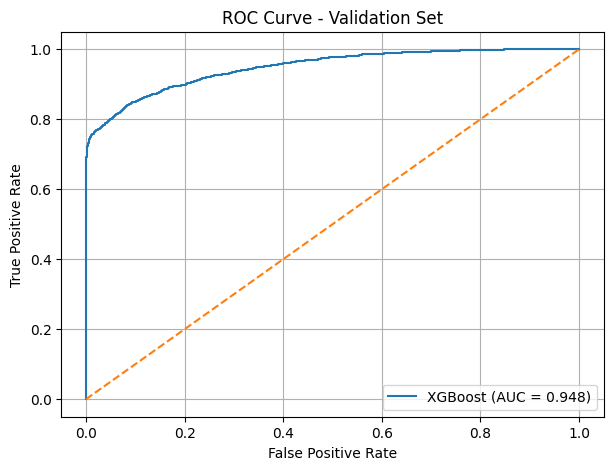

In [95]:
# ---------------------------------------------------------
# 11. ROC Curve (Validation)
# ---------------------------------------------------------
fpr, tpr, roc_thresholds = roc_curve(y_val, val_probs)
val_auc = roc_auc_score(y_val, val_probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {val_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Validation Set")
plt.legend()
plt.grid(True)
plt.show()


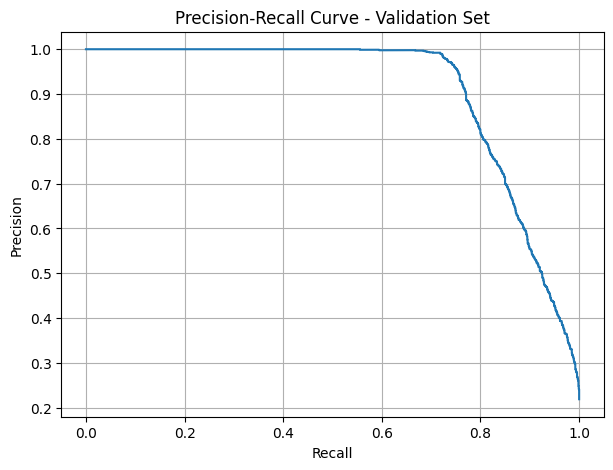

In [96]:
# ---------------------------------------------------------
# 12. Precision-Recall Curve (Validation)
# ---------------------------------------------------------
precisions, recalls, pr_thresholds = precision_recall_curve(y_val, val_probs)

plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Validation Set")
plt.grid(True)
plt.show()


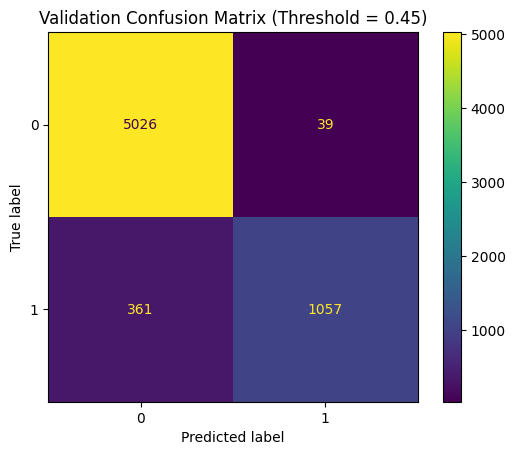

In [97]:
# ---------------------------------------------------------
# 13. Confusion Matrix (Validation)
# ---------------------------------------------------------
cm_val = confusion_matrix(y_val, val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_val)
disp.plot()
plt.title(f"Validation Confusion Matrix (Threshold = {best_threshold:.2f})")
plt.show()

In [98]:
# ---------------------------------------------------------
# 14. Final test evaluation using chosen threshold
# ---------------------------------------------------------
test_probs = model.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= best_threshold).astype(int)

print("\n=== Test Metrics ===")
print(f"Threshold : {best_threshold:.2f}")
print("Accuracy  :", accuracy_score(y_test, test_preds))
print("Precision :", precision_score(y_test, test_preds, zero_division=0))
print("Recall    :", recall_score(y_test, test_preds, zero_division=0))
print("F1 Score  :", f1_score(y_test, test_preds, zero_division=0))
print("ROC AUC   :", roc_auc_score(y_test, test_probs))

print("\nTest Classification Report:")
print(classification_report(y_test, test_preds, zero_division=0))


=== Test Metrics ===
Threshold : 0.45
Accuracy  : 0.9361505243676743
Precision : 0.9613970588235294
Recall    : 0.7376586741889986
F1 Score  : 0.8347964884277733
ROC AUC   : 0.9459664167822541

Test Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5066
           1       0.96      0.74      0.83      1418

    accuracy                           0.94      6484
   macro avg       0.95      0.86      0.90      6484
weighted avg       0.94      0.94      0.93      6484



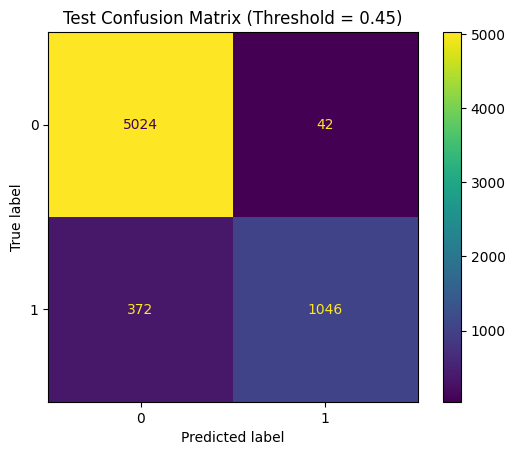

In [99]:
# ---------------------------------------------------------
# 15. Confusion Matrix (Test)
# ---------------------------------------------------------
cm_test = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp.plot()
plt.title(f"Test Confusion Matrix (Threshold = {best_threshold:.2f})")
plt.show()

In [100]:
# ---------------------------------------------------------
# 16. Sample prediction output
# ---------------------------------------------------------
test_results = X_test.copy()
test_results["actual_default"] = y_test.values
test_results["predicted_probability"] = test_probs
test_results["predicted_class"] = test_preds

print("\nSample prediction results:")
print(test_results[["actual_default", "predicted_probability", "predicted_class"]].head(10))

# Save sample predictions if needed
test_results.to_csv("XGBoost_test_predictions.csv", index=False)


Sample prediction results:
       actual_default  predicted_probability  predicted_class
21278               0               0.315064                0
26976               1               0.066657                0
26455               0               0.001532                0
24178               0               0.004289                0
25069               1               0.992650                1
28959               0               0.099929                0
28501               1               0.983512                1
8425                0               0.149900                0
29253               0               0.158710                0
30351               0               0.031078                0


In [101]:
# ---------------------------------------------------------
# 17. Feature importance from XGBoost
# ---------------------------------------------------------
ohe = model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
encoded_cat_names = ohe.get_feature_names_out(categorical_features)

all_feature_names = numeric_features + list(encoded_cat_names)
importances = model.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\nTop 20 most influential features:")
print(importance_df.head(20))

importance_df.to_csv("xgboost_feature_importance.csv", index=False)


Top 20 most influential features:
                           feature  importance
10      person_home_ownership_RENT    0.173840
5              loan_percent_income    0.100840
20                    loan_grade_D    0.075530
19                    loan_grade_C    0.073542
17                    loan_grade_A    0.054866
4                    loan_int_rate    0.052506
14             loan_intent_MEDICAL    0.050784
9        person_home_ownership_OWN    0.048489
11   loan_intent_DEBTCONSOLIDATION    0.047999
13     loan_intent_HOMEIMPROVEMENT    0.034224
1                    person_income    0.032234
7   person_home_ownership_MORTGAGE    0.031071
16             loan_intent_VENTURE    0.030105
23                    loan_grade_G    0.025434
21                    loan_grade_E    0.024598
22                    loan_grade_F    0.020372
18                    loan_grade_B    0.019911
24     cb_person_default_on_file_N    0.016222
2                person_emp_length    0.015550
12           loan_intent_

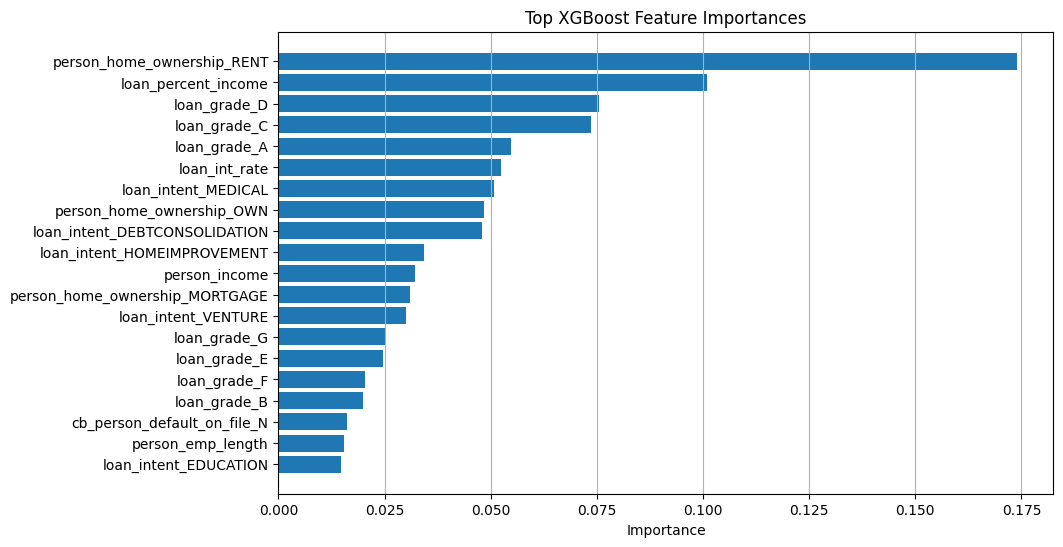

In [102]:
# ---------------------------------------------------------
# 18. Plot top XGBoost feature importances
# ---------------------------------------------------------
top_features = importance_df.head(20).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importance")
plt.title("Top XGBoost Feature Importances")
plt.grid(True, axis="x")
plt.show()

In [103]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_grid = { "classifier__n_estimators": [200, 300, 500], "classifier__max_depth": [3, 4, 5, 6], "classifier__learning_rate": [0.03, 0.05, 0.1], "classifier__min_child_weight": [1, 3, 5], "classifier__subsample": [0.7, 0.8, 0.9, 1.0], "classifier__colsample_bytree": [0.7, 0.8, 0.9, 1.0], "classifier__gamma": [0, 0.1, 0.3], "classifier__reg_alpha": [0, 0.1, 1], "classifier__reg_lambda": [1, 2, 5] }
search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=25,
    scoring="f1",
    cv=cv,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

print("Best parameters:")
print(search.best_params_)

print("\nBest CV score:")
print(search.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV] END classifier__colsample_bytree=0.8, classifier__gamma=0.1, classifier__learning_rate=0.03, classifier__max_depth=3, classifier__min_child_weight=5, classifier__n_estimators=200, classifier__reg_alpha=1, classifier__reg_lambda=1, classifier__subsample=1.0; total time=   0.4s
[CV] END classifier__colsample_bytree=0.8, classifier__gamma=0.1, classifier__learning_rate=0.03, classifier__max_depth=3, classifier__min_child_weight=5, classifier__n_estimators=200, classifier__reg_alpha=1, classifier__reg_lambda=1, classifier__subsample=1.0; total time=   0.5s
[CV] END classifier__colsample_bytree=0.8, classifier__gamma=0.1, classifier__learning_rate=0.03, classifier__max_depth=3, classifier__min_child_weight=5, classifier__n_estimators=200, classifier__reg_alpha=1, classifier__reg_lambda=1, classifier__subsample=1.0; total time=   0.5s
[CV] END classifier__colsample_bytree=0.8, classifier__gamma=0.1, classifier__learning_rate=